# E-commerce Transactions  
**Dataset:** [Online Retail Dataset (UCI / Kaggle)](https://www.kaggle.com/datasets/vijayuv/onlineretail)

Exploratory Data Analysis and visualization for a
UK-based online retailer's transaction records (Dec 2010 – Dec 2011).  

**cleaning process**: every decision is documented as it's made.

In [1]:
import pandas as pd
import numpy as np
import janitor
from plotnine import *
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
retail_raw = pd.read_csv('OnlineRetail.csv', encoding = "latin1")

## Dataset Understanding

In [3]:
# Display the first few rows
retail_raw.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
retail_raw.sample(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
143293,548673,22726,ALARM CLOCK BAKELIKE GREEN,4,4/1/2011 16:18,3.75,13767.0,United Kingdom
508340,579196,23215,JINGLE BELL HEART ANTIQUE SILVER,2,11/28/2011 15:54,4.13,14096.0,United Kingdom
144405,548740,22382,LUNCH BAG SPACEBOY DESIGN,10,4/4/2011 11:34,1.65,13319.0,United Kingdom
387825,570388,82484,WOOD BLACK BOARD ANT WHITE FINISH,2,10/10/2011 12:37,7.95,14911.0,EIRE
18938,537823,22757,LARGE RED BABUSHKA NOTEBOOK,3,12/8/2010 14:25,2.51,NaN,United Kingdom
207293,554981,84879,ASSORTED COLOUR BIRD ORNAMENT,8,5/29/2011 12:06,1.69,17613.0,United Kingdom
455778,575643,84755,COLOUR GLASS T-LIGHT HOLDER HANGING,32,11/10/2011 14:09,0.65,13267.0,United Kingdom
95755,544463,35912B,WHITE/PINK CHICK DECORATION,2,2/20/2011 14:31,1.25,12988.0,United Kingdom
469742,576607,22733,3D TRADITIONAL CHRISTMAS STICKERS,18,11/15/2011 15:42,1.25,12474.0,Germany
318839,564838,22743,MAKE YOUR OWN FLOWERPOWER CARD KIT,1,8/30/2011 12:43,5.79,NaN,United Kingdom


In [5]:
retail_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
print("Shape (rows, columns):",retail_raw.shape)

# Data types of all columns
print('')
print('Data types of all columns:', retail_raw.dtypes)

Shape (rows, columns): (541909, 8)

Data types of all columns: InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


**Brief Description: Column overview**

| Column | Type | Role |
|---|---|---|
| InvoiceNo | text (some prefixed 'C') | Transaction identifier|
| StockCode | text | Product identifier |
| Description | text | Product name (categorical) |
| Quantity | numerical | Units purchased |
| InvoiceDate | text to datetime | Transaction timestamp |
| UnitPrice | numerical | Price per unit (GBP) |
| CustomerID | numerical | Customer identifier |
| Country | text | Categorical, customer's country |

- **Numerical features:** `Quantity`, `UnitPrice`, `CustomerID` (identifiers)
- **Categorical features:** `Description`, `Country`, and `StockCode`/`InvoiceNo` (high-cardinality identifiers)
- **Possible primary key:** there's no single-column unique key. `InvoiceNo` + `StockCode` together identify a
  line item within an invoice (a composite key), since one invoice contains many products.

**What this dataset contains:** transaction-level records for a UK-based, non-store online retailer selling
mostly unique all-occasion gift-ware, covering all invoices between 01/12/2010 and 09/12/2011. Each row is
one product line on one invoice.

---

## Data Cleaning
**Missing Values**

In [7]:
print('Identifying columns with missing values')
print('Columns          Number of missing values per column')
print(retail_raw.isna().sum())

Identifying columns with missing values
Columns          Number of missing values per column
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


`Description` is missing for 1,454 rows   
`CustomerID` is missing 135,080 rows (about 25% of the data).
No other column has missing values.

### Handling missing values a

- **`Description`** since each StockCode represents one specific product, every row with that code should have the same description. Missing descriptions will be filled in by looking up the most frequently used description for that exact StockCode elsewhere in the dataset (the product's own sales history "votes" on what it's called).  

>  This is more reliable than trying to guess from the description text itself, since free-text entries can vary in capitalization, spelling, or phrasing even when they refer to the same product, whereas StockCode is a fixed identifier that doesn't drift like that. If a StockCode has no description anywhere in the data to borrow from, it will be labeled `"UNKNOWN ITEM"`


In [8]:
desc_lookup = (retail_raw.dropna(subset=['Description'])
                 .groupby('StockCode')['Description']
                 .agg(lambda x: x.value_counts().index[0]))
desc_lookup

StockCode
10002                  INFLATABLE POLITICAL GLOBE 
10080                     GROOVY CACTUS INFLATABLE
10120                                 DOGGY RUBBER
10123C                       HEARTS WRAPPING TAPE 
10124A                 SPOTS ON RED BOOKCOVER TAPE
                               ...                
gift_0001_20    Dotcomgiftshop Gift Voucher £20.00
gift_0001_30    Dotcomgiftshop Gift Voucher £30.00
gift_0001_40    Dotcomgiftshop Gift Voucher £40.00
gift_0001_50    Dotcomgiftshop Gift Voucher £50.00
m                                           Manual
Name: Description, Length: 3958, dtype: object

In [9]:
missing_desc_before = retail_raw['Description'].isna().sum()
print('missing_desc_before:', missing_desc_before)

print('')
retail_raw['Description'] = retail_raw.apply(
    lambda r: desc_lookup.get(r['StockCode'], 'UNKNOWN ITEM') if pd.isna(r['Description']) else r['Description'],
    axis=1
)

print("Missing descriptions filled:", missing_desc_before)
print("remaining NA:", retail_raw['Description'].isna().sum())

missing_desc_before: 1454

Missing descriptions filled: 1454
remaining NA: 0


### Handling missing values b
 
- **`CustomerID`** This will be left as missing rather than dropped or imputed. A missing customer ID can be a guest
  checkout, which is real and meaningful, not an error.   
  Also Dropping ~25% of transactions would throw away valid
  sales data, and there's no reliable way to guess who a guest was.
  
  Instead a boolean flag `is_guest_checkout`
  will be added so customer-level analyses (like RFM) can filter to identified customers while transaction-level
  analyses (like revenue by country) can still use every row.

In [10]:
retail_raw['is_guest_checkout'] = retail_raw['CustomerID'].isna()
retail_raw['CustomerID'] = retail_raw['CustomerID'].astype('Int64')
retail_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_guest_checkout
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,False


## Duplicate records

some rows in the data are identical (same invoice, same product, same everything). This isn't a second, separate purchase, it's almost certainly the same line item accidentally recorded twice (e.g. a scanning or export glitch). Since it doesn't represent a real second event, the repeat copy will be removed, keeping only one instance of that row.


In [36]:
print('Identify duplicate rows')
print("Duplicate rows found:", retail_raw.duplicated().sum())
print(f"Shape before removing duplicates: {retail_raw.shape}")

print('')
print('DISPLAYING THE DUPLICATED ROWS')
print(retail_raw[retail_raw.duplicated(keep=False)].sort_values(['InvoiceNo', 'StockCode'])) #groups matching pairs next to each other

retail_raw2 = retail_raw.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {retail_raw2.shape}")

Identify duplicate rows
Duplicate rows found: 5268
Shape before removing duplicates: (541909, 9)

DISPLAYING THE DUPLICATED ROWS
       InvoiceNo StockCode                          Description  Quantity  \
494       536409     21866          UNION JACK FLAG LUGGAGE TAG         1   
517       536409     21866          UNION JACK FLAG LUGGAGE TAG         1   
485       536409     22111         SCOTTIE DOG HOT WATER BOTTLE         1   
539       536409     22111         SCOTTIE DOG HOT WATER BOTTLE         1   
489       536409     22866        HAND WARMER SCOTTY DOG DESIGN         1   
...          ...       ...                                  ...       ...   
440149   C574510     22360      GLASS JAR ENGLISH CONFECTIONERY        -1   
461407   C575940     23309  SET OF 60 I LOVE LONDON CAKE CASES        -24   
461408   C575940     23309  SET OF 60 I LOVE LONDON CAKE CASES        -24   
529980   C580764     22667                RECIPE BOX RETROSPOT        -12   
529981   C580764     226

In [12]:
retail_raw2.duplicated().sum()

np.int64(0)

## Standardization 
>column names, data types, and text formatting

Actions:
- Renaming columns to lower_snake_case for consistency.
- Parsed `invoice_date` into a real datetime type (it was loaded as a string like `12/1/2010 8:26`).
- Stripped whitespace and upper-cased `description` and `stock_code` so the same product isn't split into
  multiple text variants (e.g. `"red mug "` vs `"RED MUG"`).

In [13]:
retail = retail_raw2.clean_names()
retail.head(2)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,is_guest_checkout
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,False


In [14]:
retail.columns = ['invoice_no', 'stock_code', 'description', 'quantity',
              'invoice_date', 'unit_price', 'customer_id', 'country', 'is_guest_checkout']

retail['invoice_date'] = pd.to_datetime(retail['invoice_date'], format='%m/%d/%Y %H:%M')
retail['invoice_no'] = retail['invoice_no'].astype(str).str.strip()
retail['stock_code'] = retail['stock_code'].astype(str).str.strip().str.upper()
retail['description'] = retail['description'].astype(str).str.strip().str.upper()
retail.loc[retail['description'].isin(['NAN', '']), 'description'] = np.nan
retail['country'] = retail['country'].astype(str).str.strip()

print(retail.dtypes)

invoice_no                   object
stock_code                   object
description                  object
quantity                      int64
invoice_date         datetime64[ns]
unit_price                  float64
customer_id                   Int64
country                      object
is_guest_checkout              bool
dtype: object


In [15]:
retail.head(2)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_guest_checkout
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False


---

## Data validation  
invalid values and anomalies

`Quantity` and `UnitPrice` has a few distinct issues:

1. **Cancellations** - invoices starting with `C` carry negative quantities (returns/cancellations).
   These are real events, so they are **kept but will be flagged** with `is_cancelled` rather than deleted.
   
2. **Orphan negative-quantity rows** - 1,336 rows have negative quantity, are *not* cancellations, have
   `unit_price == 0`, and have no `customer_id`. These look like internal stock write-off/adjustment
   entries, not customer transactions, so they add noise without adding sales signal. **They will be removed.**

   
3. **"Adjust bad debt" entries** - some rows use `stock_code == 'B'` with a large negative `unit_price`,
   which is an accounting ledger entry, not a product sale. **Removed** since it isn't a real transaction.

   
4. **Non-product stock codes** - codes like `POST` (postage), `DOT`, `M` (manual), `C2` (carriage), `D`
   (discount), `BANK CHARGES`, `S`, `AMAZONFEE`, `CRUK` are fees/adjustments rather than merchandise.
   These are **kept** (they're valid rows) but **flagged** with `is_product = False` so they can be excluded
   from product-level analyses like "top-selling products."

   
5. **Zero-price rows** - likely free promotional items or samples. **Kept but flagged** (`is_zero_price`)
   since the transaction itself is real, only the revenue value is zero.

In [16]:
# Flag cancellations

# labeling all invoice_no that starts with the letter C (like C536379) as cancelled 
#and creating a column for canceled and not canceled orders
retail['is_cancelled'] = retail['invoice_no'].str.startswith('C')

# Remove negative-quantity adjustment rows (no customer, $0 price, not a cancellation)
invalid_mask = (retail['quantity'] < 0) & (~retail['is_cancelled']) & (retail['customer_id'].isna())

# print how many rows are about to be removed.
print("Invalid stock-adjustment rows removed:", invalid_mask.sum())
# ~invalid_mask flips True/Fals, keeping "rows that are NOT invalid
retail = retail[~invalid_mask].reset_index(drop=True)

# Remove 'Adjust bad debt' ledger entries
bad_debt_mask = retail['stock_code'] == 'B'
print("Bad-debt ledger rows removed:", bad_debt_mask.sum())
retail = retail[~bad_debt_mask].reset_index(drop=True)

print("Shape after validation cleanup:", retail.shape)

Invalid stock-adjustment rows removed: 1336
Bad-debt ledger rows removed: 3
Shape after validation cleanup: (535302, 10)


## Feature Engineering

- Non-product rows: some **stock_code** values (like POST, BANK CHARGES, D) aren't missing anything, they're fully filled in, but they represent fees or adjustments rather than an actual product being sold. 
These rows are still real and valid (someone genuinely paid postage), so they will be kept rather than deleted.  
Instead, a flag **is_product** will be used to mark whether a row is an actual product   

>Analyses like "top-selling products" can exclude postage/fees automatically, while analyses like "total revenue collected" can still count them.


- Zero-price rows: some rows have a normal, positive quantity but a unit_price of exactly 0, most likely a free promotional item or sample. Nothing is missing here, the transaction happened, it just generated no revenue. These will be kept and flagged with **is_zero_price**, so revenue or pricing analyses can choose to exclude them without losing the row entirely.

- total_price (quantity × unit_price)

In [17]:
non_product_codes = {'POST', 'DOT', 'M', 'C2', 'D', 'BANK CHARGES', 'S', 'AMAZONFEE', 'CRUK', 'PADS'}
retail['is_product'] = ~retail['stock_code'].isin(non_product_codes)

retail['is_zero_price'] = retail['unit_price'] == 0

retail['total_price'] = retail['quantity'] * retail['unit_price']


retail.isna().sum()

invoice_no                0
stock_code                0
description               0
quantity                  0
invoice_date              0
unit_price                0
customer_id          133698
country                   0
is_guest_checkout         0
is_cancelled              0
is_product                0
is_zero_price             0
total_price               0
dtype: int64

In [18]:
retail.head(1)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_guest_checkout,is_cancelled,is_product,is_zero_price,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,False,True,False,15.3


##  Cleaning summary

| Issue Found | Action Taken |
|---|---|
| Missing `description` (1,454 rows) | Filled from the most common description for that `stock_code`; unresolved cases set to `"UNKNOWN ITEM"` |
| Missing `customer_id` (135,080 rows) | Kept and flagged as `is_guest_checkout` rather than dropped or imputed |
| Duplicate rows (5,268) | Removed |
| Orphan negative-quantity adjustment rows (1,336) | Removed (no customer, $0 price, not a real sale) |
| "Adjust bad debt" ledger rows (3) | Removed (accounting entry, not a transaction) |
| Non-product stock codes (postage, fees, etc.) | Kept, flagged with `is_product = False` |
| Cancelled orders (`InvoiceNo` starting with `C`) | Kept, flagged with `is_cancelled = True` |
| Zero-price rows | Kept, flagged with `is_zero_price = True` |
| Inconsistent text casing/whitespace | Standardized to upper case, trimmed |
| Column names | Standardized to lower_snake_case |
| `invoice_date` stored as text | Converted to datetime |

Final cleaned shape:

In [19]:
print(retail.shape)
#retail.to_csv('OnlineRetail_cleaned.csv', index=False)
print("Saved clean csv")

(535302, 13)
Saved clean csv


---
## Exploratory Data Analysis

For the EDA below, cancellations and non-product rows are excluded where they'd distort a "sales" metric —
this is noted in each analysis.

In [20]:
# ~retail  means "is NOT cancelled," i.e., keep only real, completed sales
sales = retail[(~retail['is_cancelled']) & (retail['is_product'])].copy()
# filtering only the rows from retail that satisfy both conditions(is not cancelled AND is an actual product((not postage, fees, etc))
print("Rows used for sales analyses:", sales.shape[0])

Rows used for sales analyses: 523727


### Summary statistics 
Numerical columns

In [21]:
retail[['quantity', 'unit_price', 'total_price']].describe().rename(index={'50%':'median'})

,quantity,unit_price,total_price
count,535302.000000,535302.000000,535302.000000
mean,10.030704,4.664909,18.189861
std,217.272390,93.765054,380.229233
min,-80995.000000,0.000000,-168469.600000
25%,1.000000,1.250000,3.750000
median,3.000000,2.080000,9.900000
75%,10.000000,4.130000,17.400000
max,80995.000000,38970.000000,168469.600000


#### **Top-selling products (by quantity sold)**

In [22]:
top_products_qty = (sales.groupby('description')['quantity'].sum()
                     .sort_values(ascending=False).head(10).reset_index())
top_products_qty

,description,quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3,JUMBO BAG RED RETROSPOT,48375
4,WHITE HANGING HEART T-LIGHT HOLDER,37876
5,POPCORN HOLDER,36749
6,PACK OF 72 RETROSPOT CAKE CASES,36396
7,ASSORTED COLOUR BIRD ORNAMENT,36362
8,RABBIT NIGHT LIGHT,31555
9,MINI PAINT SET VINTAGE,26633


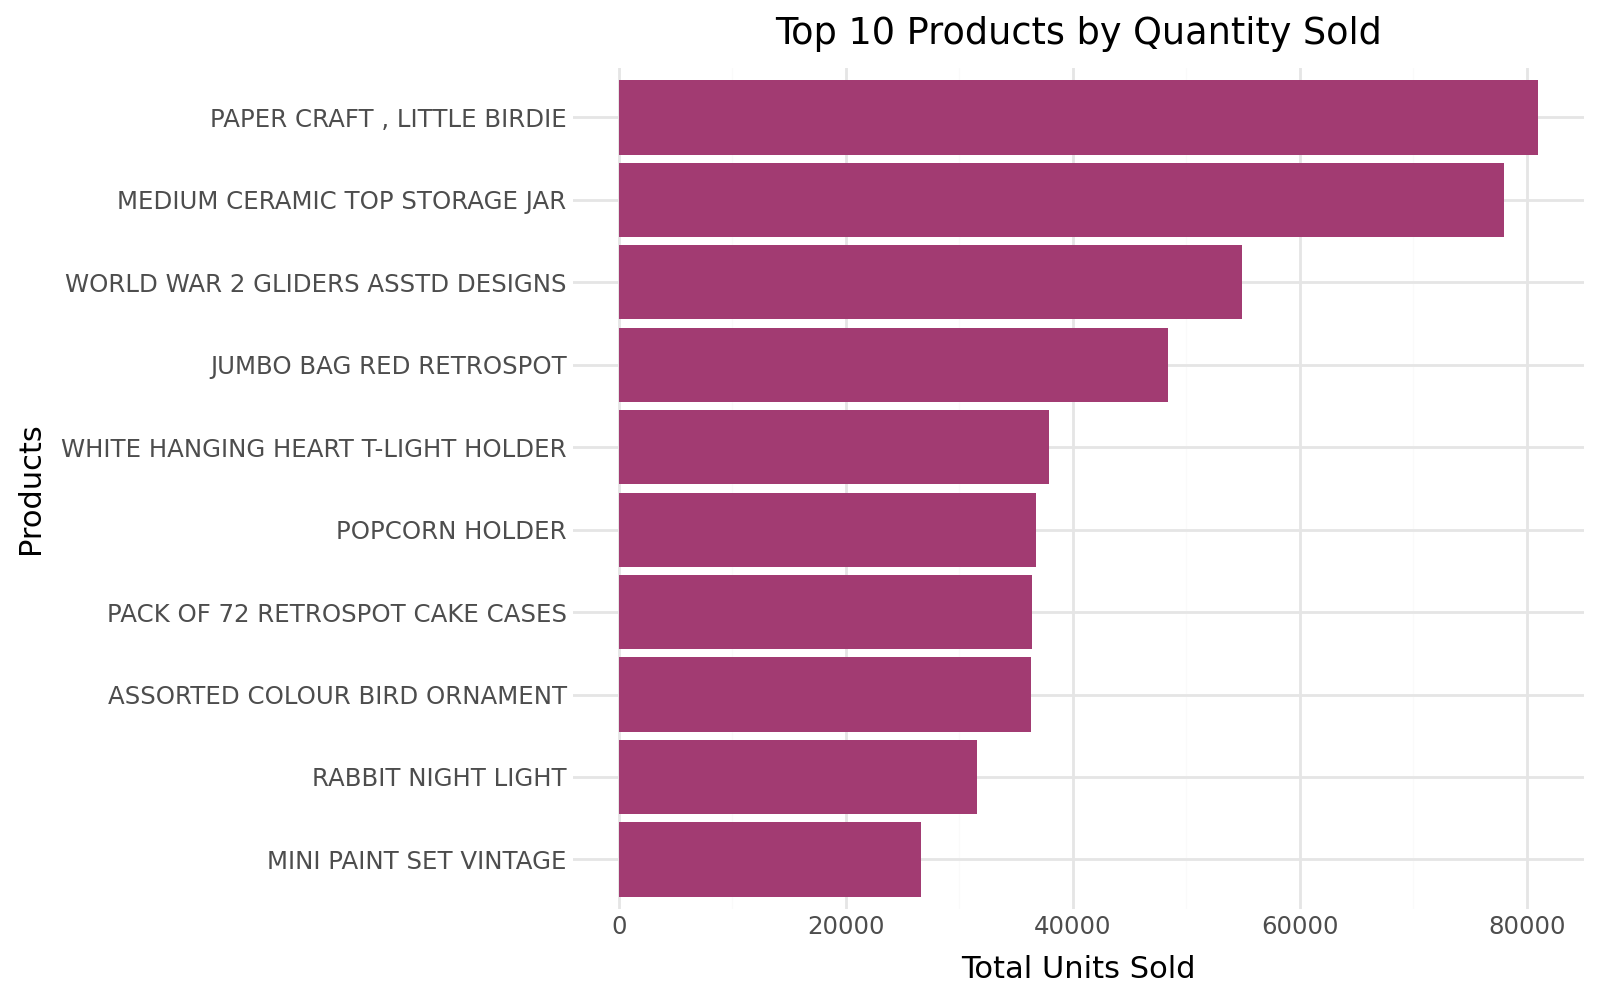

In [23]:
top10_qty_df = top_products_qty
top10_qty_df.columns = ['description', 'quantity']
top10_qty_df['description'] = pd.Categorical(top10_qty_df['description'],
                                              categories=top10_qty_df.sort_values('quantity')['description'],
                                              ordered=True)

(ggplot(top10_qty_df, aes(x='description', y='quantity'))
 + geom_col(fill='#A23B72')
 + coord_flip()
 + labs(title='Top 10 Products by Quantity Sold', x='Products', y='Total Units Sold')
 + theme_minimal()
 + theme(figure_size=(8, 5)))

**A small number of "bulk favorite" products drive volume.** Items like "Paper Craft, Little Birdie" and
   "Medium Ceramic Top Storage Jar" are bought in far larger quantities per order than typical products,
   suggesting wholesale/reseller customers rather than individual gift-buyers 

 #### **Highest revenue-generating countries**

In [24]:
top_countries_rev = (sales.groupby('country')['total_price'].sum()
                      .sort_values(ascending=False).head(10)).reset_index()
top_countries_rev

,country,total_price
0,United Kingdom,8725129.48
1,Netherlands,283889.34
2,EIRE,270850.86
3,Germany,205381.15
4,France,184493.00
5,Australia,138103.81
6,Spain,55706.56
7,Switzerland,53065.60
8,Japan,37416.37
9,Belgium,36927.34


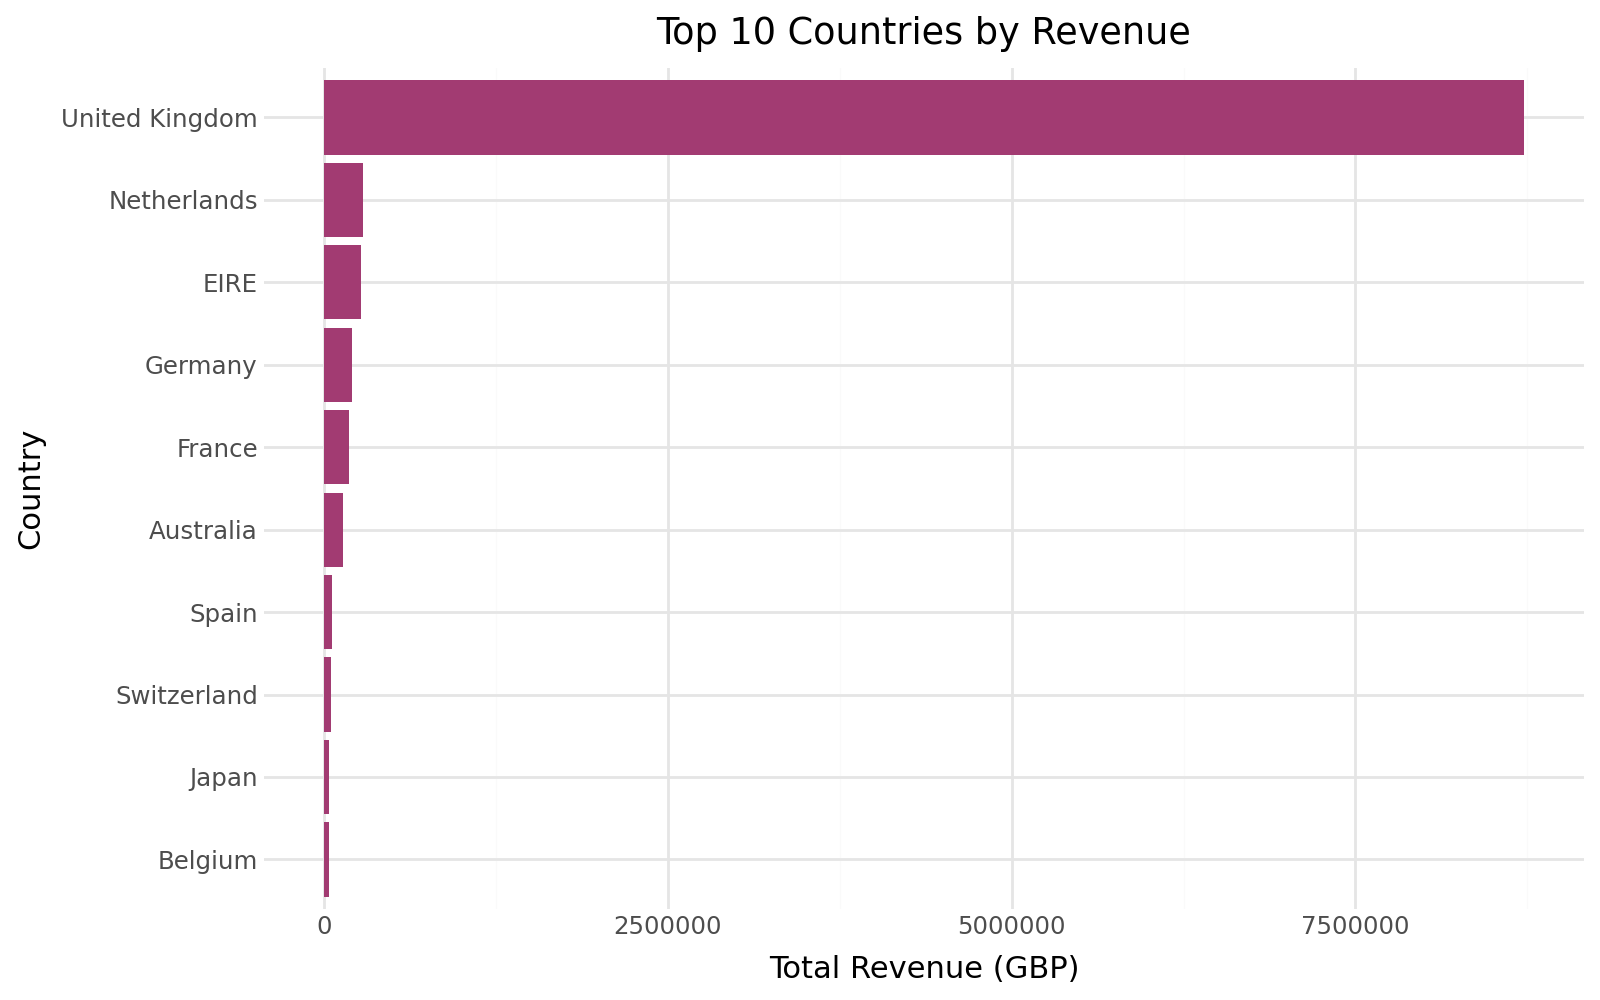

In [25]:
top10_country_df = top_countries_rev
top10_country_df.columns = ['country', 'revenue']
top10_country_df['country'] = pd.Categorical(top10_country_df['country'],
                                              categories=top10_country_df.sort_values('revenue')['country'],
                                              ordered=True)

(ggplot(top10_country_df, aes(x='country', y='revenue'))
 + geom_col(fill='#A23B72')
 + coord_flip()
 + labs(title='Top 10 Countries by Revenue', x='Country', y='Total Revenue (GBP)')
 + theme_minimal()
 + theme(figure_size=(8, 5)))

**The United Kingdom generates roughly 30x the revenue of the next
   closest country (Netherlands)**, Given this is a UK-based retailer, it means the
   business has meaningful exposure to a single market.

### **Monthly sales trend**

In [26]:
monthly_sales = (sales.set_index('invoice_date')['total_price']
                  .resample('MS').sum())
monthly_sales

invoice_date
2010-12-01     775714.95
2011-01-01     670439.46
2011-02-01     507866.54
2011-03-01     689841.84
2011-04-01     515469.66
2011-05-01     740036.33
2011-06-01     737683.99
2011-07-01     688252.67
2011-08-01     724308.16
2011-09-01    1028345.38
2011-10-01    1103330.92
2011-11-01    1452115.98
2011-12-01     614499.25
Freq: MS, Name: total_price, dtype: float64

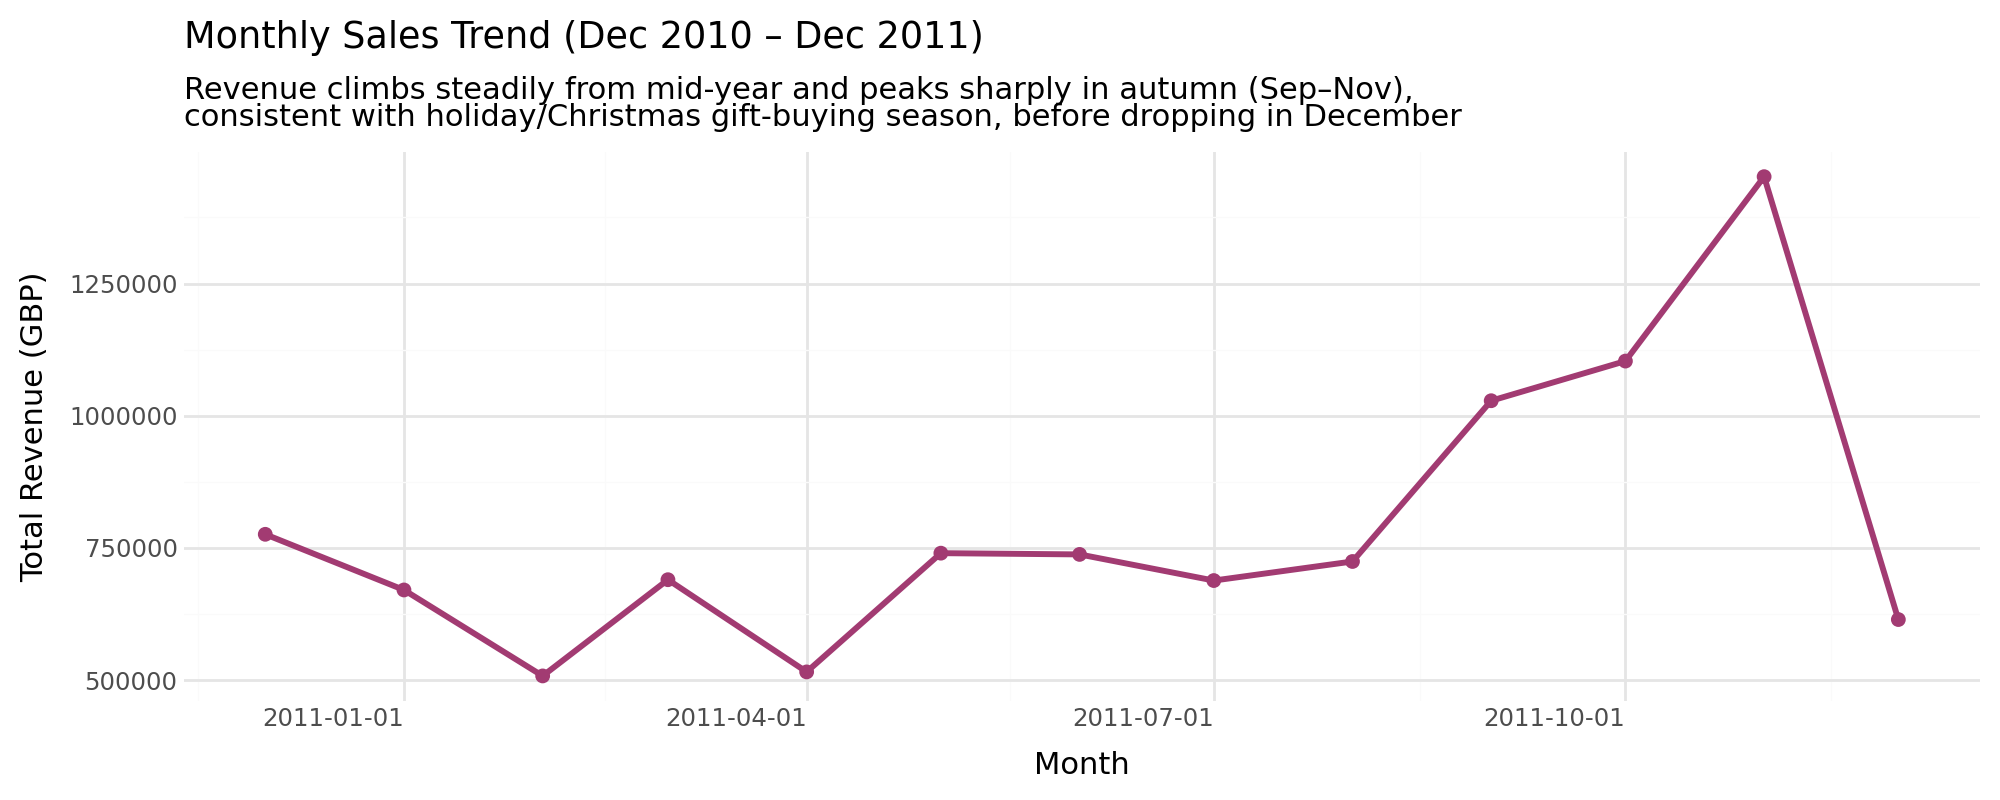

In [27]:
monthly_df = monthly_sales.reset_index()
monthly_df.columns = ['month', 'revenue']

(ggplot(monthly_df, aes(x='month', y='revenue'))
 + geom_line(color='#A23B72', size=1.2)
 + geom_point(color='#A23B72', size=2)
 + labs(title='Monthly Sales Trend (Dec 2010 – Dec 2011)', x='Month', y='Total Revenue (GBP)',
       subtitle= 'Revenue climbs steadily from mid-year and peaks sharply in autumn (Sep–Nov), \nconsistent with holiday/Christmas gift-buying season, before dropping in December')
 + theme_minimal()
 + theme(figure_size=(10, 4), axis_text_x=element_text(hjust=1)))

**Sales are strongly seasonal.** Monthly revenue nearly doubles between the summer months and the autumn
   peak, pointing to a business that should plan inventory and staffing around a Sep–Nov surge tied to
   Christmas gift purchasing

#### **Most purchased products (by number of orders/invoices they appear in)**

In [28]:
most_purchased = (sales.groupby('description')['invoice_no'].nunique()
                   .sort_values(ascending=False).head(10))
most_purchased

description
WHITE HANGING HEART T-LIGHT HOLDER    2260
JUMBO BAG RED RETROSPOT               2092
REGENCY CAKESTAND 3 TIER              1989
PARTY BUNTING                         1686
LUNCH BAG RED RETROSPOT               1564
ASSORTED COLOUR BIRD ORNAMENT         1455
SET OF 3 CAKE TINS PANTRY DESIGN      1387
PACK OF 72 RETROSPOT CAKE CASES       1320
LUNCH BAG  BLACK SKULL.               1273
NATURAL SLATE HEART CHALKBOARD        1249
Name: invoice_no, dtype: int64

### **Customer purchasing behavior**

Looking only at identified customers (guest checkouts excluded, since there's no way to link their orders
together): number of orders per customer and average order value.

In [29]:
identified = sales[~sales['is_guest_checkout']]

orders_per_customer = identified.groupby('customer_id')['invoice_no'].nunique()
order_value = identified.groupby('invoice_no')['total_price'].sum()

print("Orders per customer:")
print(orders_per_customer.describe())
print()
print("Order value (per invoice):")
print(order_value.describe())

Orders per customer:
count    4335.000000
mean        4.245675
std         7.636337
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       206.000000
Name: invoice_no, dtype: float64

Order value (per invoice):
count     18405.000000
mean        474.720328
std        1678.660026
min           0.000000
25%         157.090000
50%         301.630000
75%         463.010000
max      168469.600000
Name: total_price, dtype: float64


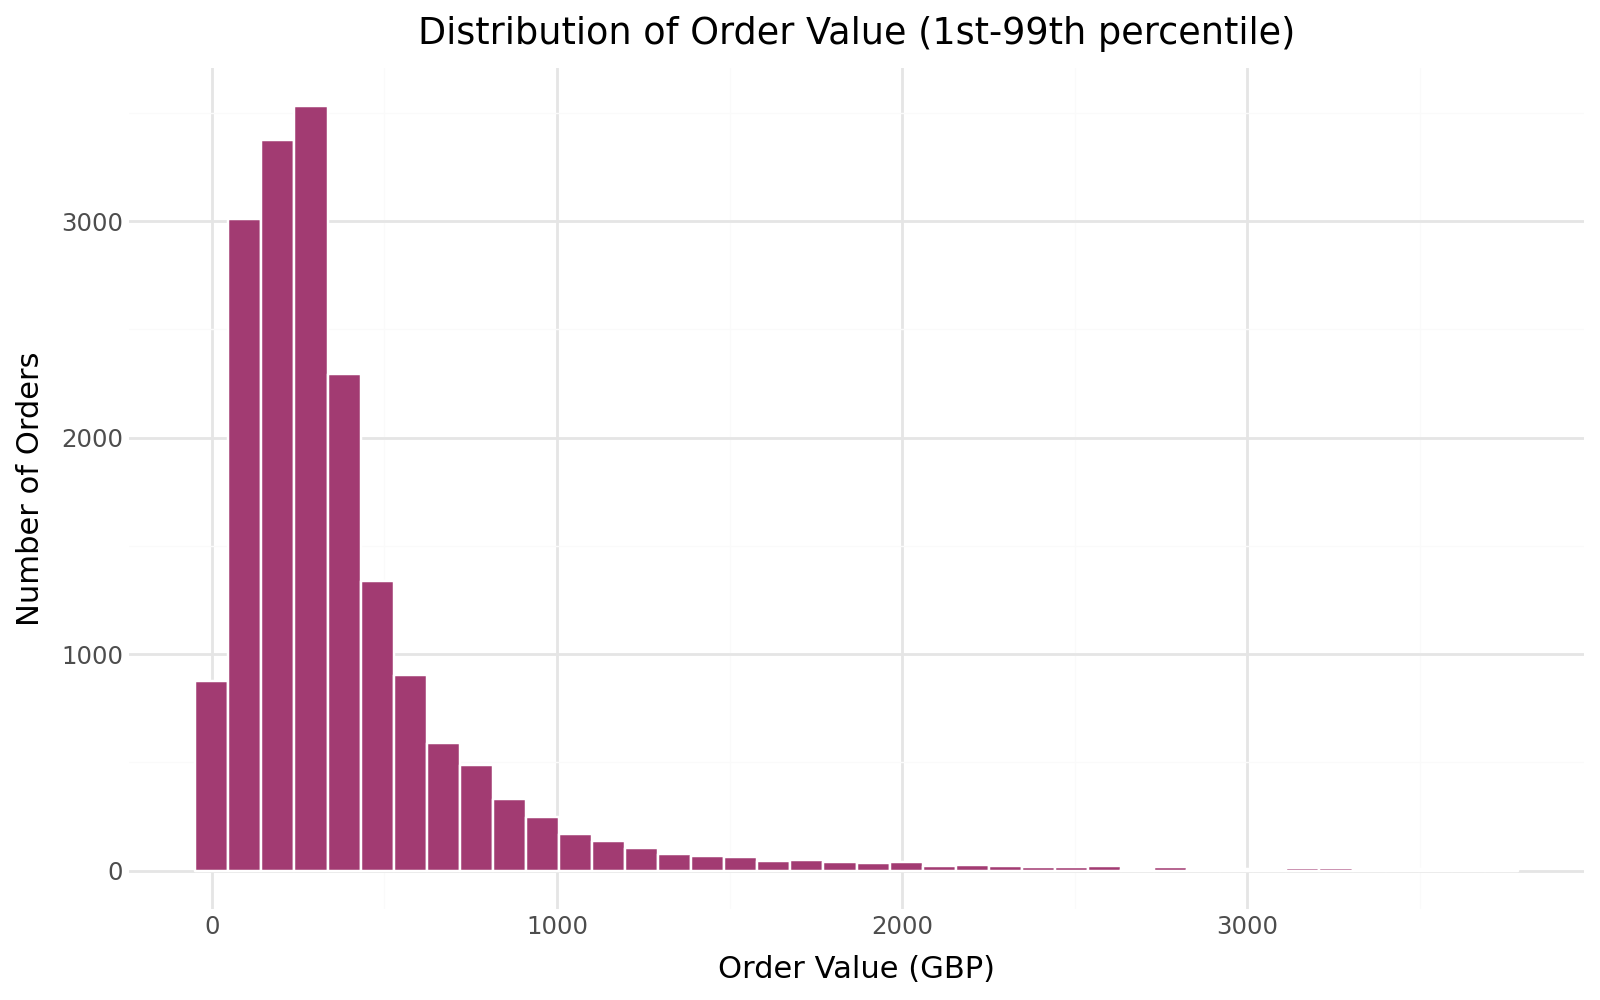

In [30]:
order_value_df = order_value.reset_index()
order_value_df.columns = ['invoice_no', 'order_value']
# Trim to the 1st-99th percentile purely for readability of the histogram
low, high = order_value_df['order_value'].quantile([0.01, 0.99])
plot_df = order_value_df[(order_value_df['order_value'] >= low) & (order_value_df['order_value'] <= high)]

(ggplot(plot_df, aes(x='order_value'))
 + geom_histogram(bins=40, fill='#A23B72', color='white')
 + labs(title='Distribution of Order Value (1st-99th percentile)', x='Order Value (GBP)', y='Number of Orders')
 + theme_minimal()
 + theme(figure_size=(8, 5)))

most orders are modest in value, with a long right tail. Order value is heavily right-skewed, so the mean order value is pulled well above the median (a small number of bulk/wholesale orders drive average revenue up).

**Order value is right-skewed, not normally distributed.** Most orders are small, but a long tail of large
   orders pulls the average order value well above the median   
   >Average order value
   alone can be a misleading metric for this business

#### **Unit price distribution for top-selling products**

In [31]:
top5_names = top_products_qty.head(5)['description'].tolist()

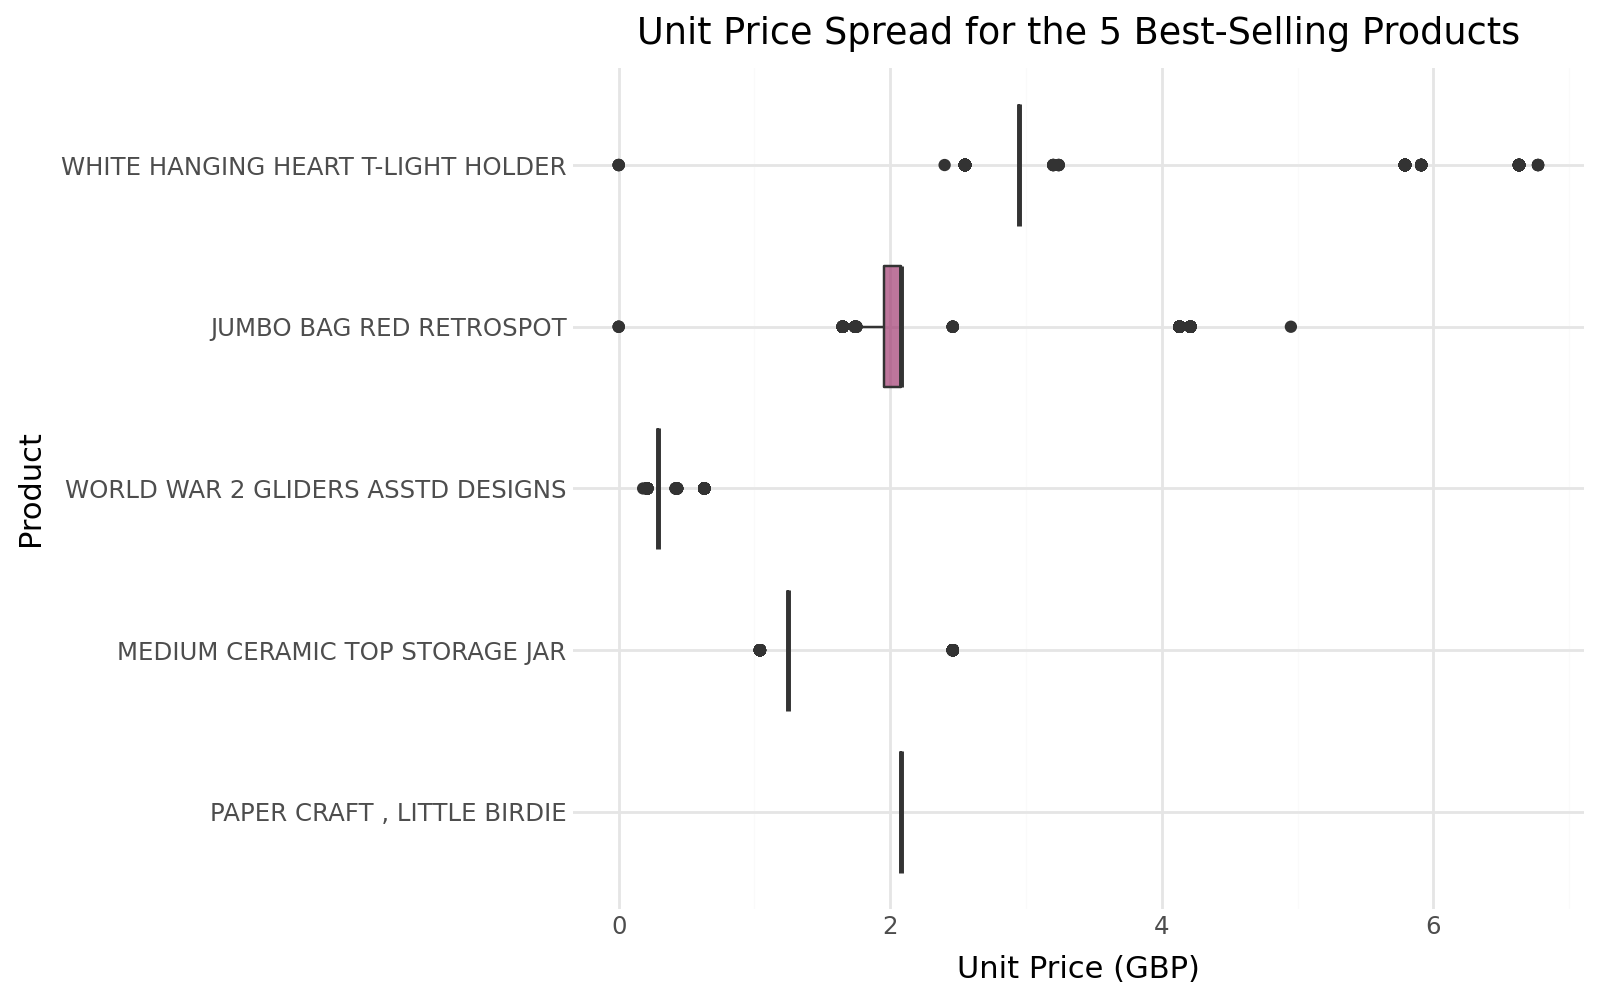

In [32]:
box_df = sales[sales['description'].isin(top5_names)].copy()
box_df['description'] = pd.Categorical(box_df['description'], categories=top5_names, ordered=True)

(ggplot(box_df, aes(x='description', y='unit_price'))
 + geom_boxplot(fill='#A23B72', alpha=0.7)
 + coord_flip()
 + labs(title='Unit Price Spread for the 5 Best-Selling Products', x='Product', y='Unit Price (GBP)')
 + theme_minimal()
 + theme(figure_size=(8, 5)))

unit prices for these bestsellers are tightly clustered with few outliers, meaning their high sales volume reflects genuine popularity rather than fluctuating/discounted pricing.

 **~25% of transactions are guest checkouts with no customer ID.** This limits how much customer-level
   analysis (repeat purchase rate, lifetime value) can be done on the full dataset, since only about 3
   quarters of transactions can be tied back to an identified customer.